In [26]:
# ============================================================
# IMPORT DES BIBLIOTHEQUES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
import warnings
from datetime import datetime

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
    average_precision_score, roc_curve, auc, precision_recall_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split

# Autres modèles pour comparaison
from xgboost import XGBClassifier


from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore')

# Configuration des styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("[OK] Toutes les bibliotheques sont chargees")

[OK] Toutes les bibliotheques sont chargees


In [ ]:
# ============================================================
# CONFIGURATION DES CHEMINS
# ============================================================

BASE_DIR = r"C:\Users\Dr_Denise\Documents\GitHub\mineralchainProjet\modele_ia_minier"

MODELS_DIR = os.path.join(BASE_DIR, "modeles")
VIZ_DIR = os.path.join(BASE_DIR, "visualisations")
REPORTS_DIR = os.path.join(BASE_DIR, "rapports")
RESULTS_DIR = REPORTS_DIR  
DATA_DIR = os.path.join(BASE_DIR, "data")

for d in [BASE_DIR, MODELS_DIR, VIZ_DIR, REPORTS_DIR, DATA_DIR]:
    os.makedirs(d, exist_ok=True)

print("[OK] Configuration des chemins terminee")

[OK] Configuration des chemins terminee


In [29]:
# ============================================================
# CHARGEMENT DU DATASET
# ============================================================

print("\n" + "="*60)
print("CHARGEMENT DU DATASET")
print("="*60)

CSV_FILE = r"C:\Users\Dr_Denise\Documents\GitHub\mineralchainProjet\modele_ia_minier\dataset_minier.csv"

try:
    df = pd.read_csv(CSV_FILE)
    print("[OK] Dataset charge: {} lignes, {} colonnes".format(df.shape[0], df.shape[1]))
except FileNotFoundError:
    print("[ERREUR] Fichier non trouve: {}".format(CSV_FILE))
    raise

print("\nApercu des premieres lignes:")
print(df.head())

print("\nColonnes disponibles:")
print(list(df.columns))


CHARGEMENT DU DATASET
[OK] Dataset charge: 50000 lignes, 20 colonnes

Apercu des premieres lignes:
      Lot_ID   Mineral_Type      Cu_%      Co_%       Fe_%      Ni_%  \
0  LOT-00001  Copper-Cobalt  6.374082  1.080688  10.602485  0.316945   
1  LOT-00002         Copper  5.458881  0.226005  14.923680  0.604278   
2  LOT-00003         Copper  4.556950  0.305600  12.766209  0.981265   
3  LOT-00004         Copper  4.471256  0.468020  13.882306  0.839379   
4  LOT-00005  Copper-Cobalt  4.935274  0.812286  10.554297  1.266486   

       Mn_%       S_%  Moisture_%  Density_g_cm3  Weight_tonnes  declared_cu  \
0  0.705197  1.554936    4.483394       3.259575      24.341853     6.333254   
1  0.344782  0.753210    6.079975       3.436075      31.022435     5.335967   
2  0.490382  1.335727    8.223233       3.234530      15.356744     4.664583   
3  0.346731  1.368310    7.331277       3.540041      36.068436     4.363512   
4  0.855942  0.844067    6.148481       3.902273      22.285240    

In [4]:
# ============================================================
# SPLIT TRAIN / VALIDATION / TEST AVEC STRATIFICATION
# ============================================================

from sklearn.model_selection import train_test_split

print("\n" + "="*60)
print("SPLIT DES DONNEES AVEC STRATIFICATION")
print("="*60)

# Stratification sur la fraude
if 'fraud_flag' in df.columns:
    stratify_col = df['fraud_flag']
    print("[OK] Stratification basee sur fraud_flag")
else:
    stratify_col = None
    print("[ATTENTION] Pas de stratification")

# Train 70% / Temp 30%
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=stratify_col
)

# Validation 15% / Test 15%
if stratify_col is not None:
    stratify_temp = temp_df['fraud_flag']
else:
    stratify_temp = None

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=stratify_temp
)

# Réinitialisation des index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nRepartition :")
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

# Vérification des fraudes
if 'fraud_flag' in df.columns:

    print("\nDistribution des fraudes :")

    print(
        "Train      : {:.2f}%".format(
            train_df['fraud_flag'].mean()*100
        )
    )

    print(
        "Validation : {:.2f}%".format(
            val_df['fraud_flag'].mean()*100
        )
    )

    print(
        "Test       : {:.2f}%".format(
            test_df['fraud_flag'].mean()*100
        )
    )

print("\n[OK] train_df, val_df et test_df recrees")


SPLIT DES DONNEES AVEC STRATIFICATION
[OK] Stratification basee sur fraud_flag

Repartition :
Train      : 35000
Validation : 7500
Test       : 7500

Distribution des fraudes :
Train      : 15.00%
Validation : 15.00%
Test       : 15.00%

[OK] train_df, val_df et test_df recrees


In [5]:
# ------------------------------------------------------------
# VERIFICATION DE LA DISTRIBUTION DES MINERAIS
# ------------------------------------------------------------

if 'Mineral_Type' in df.columns:

    print("\nDistribution des types de minerais (%)")

    print("\nTRAIN")
    print(
        (train_df['Mineral_Type']
         .value_counts(normalize=True)
         * 100)
         .round(2)
    )

    print("\nVALIDATION")
    print(
        (val_df['Mineral_Type']
         .value_counts(normalize=True)
         * 100)
         .round(2)
    )

    print("\nTEST")
    print(
        (test_df['Mineral_Type']
         .value_counts(normalize=True)
         * 100)
         .round(2)
    )


Distribution des types de minerais (%)

TRAIN
Mineral_Type
Copper-Cobalt    37.22
Copper           29.91
Mixed_Ore        17.89
Cobalt           14.98
Name: proportion, dtype: float64

VALIDATION
Mineral_Type
Copper-Cobalt    36.89
Copper           30.12
Mixed_Ore        18.16
Cobalt           14.83
Name: proportion, dtype: float64

TEST
Mineral_Type
Copper-Cobalt    36.07
Copper           30.28
Mixed_Ore        18.37
Cobalt           15.28
Name: proportion, dtype: float64


In [6]:
# ============================================================
# PREPARATION DES DONNEES (FEATURES)
# ============================================================

print("\n" + "="*60)
print("PREPARATION DES DONNEES")
print("="*60)

# ------------------------------------------------------------
# VARIABLES PHYSICO-CHIMIQUES UTILISEES
# ------------------------------------------------------------

feature_columns = [
    'Cu_%',
    'Co_%',
    'Fe_%',
    'Ni_%',
    'Mn_%',
    'S_%',
    'Moisture_%',
    'Density_g_cm3',
    'Weight_tonnes'
]

# Conserver uniquement les colonnes réellement présentes
feature_columns = [
    col for col in feature_columns
    if col in train_df.columns
]

# Vérification de sécurité
assert len(feature_columns) > 0, \
    "ERREUR : aucune feature valide trouvée"

print("\nFeatures utilisees ({}) :".format(len(feature_columns)))

for i, col in enumerate(feature_columns, start=1):
    print("  {}. {}".format(i, col))

# ------------------------------------------------------------
# PREPARATION DES MATRICES DE FEATURES
# ------------------------------------------------------------

def prepare_X(data):

    X = data[feature_columns].copy()

    # Remplacement des valeurs infinies
    X.replace([np.inf, -np.inf], np.nan, inplace=True)

    return X

print("\n[1/5] Construction des matrices X")

X_train_raw = prepare_X(train_df)
X_val_raw = prepare_X(val_df)
X_test_raw = prepare_X(test_df)

# ------------------------------------------------------------
# ANALYSE DES VALEURS MANQUANTES
# ------------------------------------------------------------

print("[2/5] Analyse des valeurs manquantes")

missing_train = X_train_raw.isnull().sum().sum()
missing_val = X_val_raw.isnull().sum().sum()
missing_test = X_test_raw.isnull().sum().sum()

print("  Train      :", missing_train)
print("  Validation :", missing_val)
print("  Test       :", missing_test)

# ------------------------------------------------------------
# IMPUTATION DES VALEURS MANQUANTES
# ------------------------------------------------------------

print("[3/5] Imputation par la moyenne")

train_means = X_train_raw.mean()

X_train_raw = X_train_raw.fillna(train_means)
X_val_raw = X_val_raw.fillna(train_means)
X_test_raw = X_test_raw.fillna(train_means)

# Vérification après imputation
assert X_train_raw.isnull().sum().sum() == 0
assert X_val_raw.isnull().sum().sum() == 0
assert X_test_raw.isnull().sum().sum() == 0

print("  [OK] Toutes les valeurs manquantes ont ete traitees")

# ------------------------------------------------------------
# NORMALISATION
# ------------------------------------------------------------

print("[4/5] Standardisation des donnees")

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

# ------------------------------------------------------------
# INFORMATIONS FINALES
# ------------------------------------------------------------

print("[5/5] Verification finale")

print("\nDimensions finales :")

print("  X_train :", X_train.shape)
print("  X_val   :", X_val.shape)
print("  X_test  :", X_test.shape)

print("\nStatistiques des features :")

for col in feature_columns:
    print(
        "  {:<18} Moy={:.3f}  Std={:.3f}".format(
            col,
            train_df[col].mean(),
            train_df[col].std()
        )
    )

print("\n[OK] Donnees preparees avec succes")


PREPARATION DES DONNEES

Features utilisees (9) :
  1. Cu_%
  2. Co_%
  3. Fe_%
  4. Ni_%
  5. Mn_%
  6. S_%
  7. Moisture_%
  8. Density_g_cm3
  9. Weight_tonnes

[1/5] Construction des matrices X
[2/5] Analyse des valeurs manquantes
  Train      : 0
  Validation : 0
  Test       : 0
[3/5] Imputation par la moyenne
  [OK] Toutes les valeurs manquantes ont ete traitees
[4/5] Standardisation des donnees
[5/5] Verification finale

Dimensions finales :
  X_train : (35000, 9)
  X_val   : (7500, 9)
  X_test  : (7500, 9)

Statistiques des features :
  Cu_%               Moy=5.085  Std=2.194
  Co_%               Moy=0.720  Std=0.476
  Fe_%               Moy=11.987  Std=3.001
  Ni_%               Moy=0.800  Std=0.200
  Mn_%               Moy=0.501  Std=0.150
  S_%                Moy=1.200  Std=0.401
  Moisture_%         Moy=5.991  Std=1.998
  Density_g_cm3      Moy=3.499  Std=0.400
  Weight_tonnes      Moy=24.973  Std=6.011

[OK] Donnees preparees avec succes


In [7]:
# ============================================================
# PREPARATION DES CIBLES
# ============================================================

print("\n" + "="*60)
print("PREPARATION DES CIBLES")
print("="*60)

targets_available = []

# ------------------------------------------------------------
# CIBLE 1 : IDENTIFICATION DU MINERAI STRATEGIQUE
# ------------------------------------------------------------

if 'Mineral_Type' in train_df.columns:

    le_mineral = LabelEncoder()

    y_train_mineral = le_mineral.fit_transform(
        train_df['Mineral_Type']
    )

    y_val_mineral = le_mineral.transform(
        val_df['Mineral_Type']
    )

    y_test_mineral = le_mineral.transform(
        test_df['Mineral_Type']
    )

    targets_available.append('mineral')

    print("\n[OK] Cible 'Mineral_Type' encodee")

    print("Classes disponibles :")
    print(list(le_mineral.classes_))

# ------------------------------------------------------------
# CIBLE 2 : NIVEAU D'IMPURETE
# ------------------------------------------------------------

if 'Impurity_Level' in train_df.columns:

    le_impurity = LabelEncoder()

    y_train_impurity = le_impurity.fit_transform(
        train_df['Impurity_Level']
    )

    y_val_impurity = le_impurity.transform(
        val_df['Impurity_Level']
    )

    y_test_impurity = le_impurity.transform(
        test_df['Impurity_Level']
    )

    targets_available.append('impurity')

    print("\n[OK] Cible 'Impurity_Level' encodee")

    print("Classes :")
    print(list(le_impurity.classes_))

# ------------------------------------------------------------
# CIBLE 3 : AUTHENTIFICATION (FRAUDE)
# ------------------------------------------------------------

if 'fraud_flag' in train_df.columns:

    y_train_fraud = train_df['fraud_flag'].astype(int).values
    y_val_fraud = val_df['fraud_flag'].astype(int).values
    y_test_fraud = test_df['fraud_flag'].astype(int).values

    # Reutiliser le split standard pour la fraude; le modele est deja equilibre via class_weight.
    X_train_fraud = X_train
    y_train_fraud_balanced = y_train_fraud

    targets_available.append('fraud')

    print("\n[OK] Cible 'fraud_flag' encodee")

    print(
        "Train      : {} fraudes ({:.2f}%)".format(
            y_train_fraud.sum(),
            y_train_fraud.mean()*100
        )
    )

    print(
        "Validation : {} fraudes ({:.2f}%)".format(
            y_val_fraud.sum(),
            y_val_fraud.mean()*100
        )
    )

    print(
        "Test       : {} fraudes ({:.2f}%)".format(
            y_test_fraud.sum(),
            y_test_fraud.mean()*100
        )
    )

# ------------------------------------------------------------
# RESUME
# ------------------------------------------------------------

print("\nTargets disponibles :")
print(targets_available)

print("\n[OK] Preparation des cibles terminee")


PREPARATION DES CIBLES

[OK] Cible 'Mineral_Type' encodee
Classes disponibles :
['Cobalt', 'Copper', 'Copper-Cobalt', 'Mixed_Ore']

[OK] Cible 'Impurity_Level' encodee
Classes :
['High', 'Normal']

[OK] Cible 'fraud_flag' encodee
Train      : 5250 fraudes (15.00%)
Validation : 1125 fraudes (15.00%)
Test       : 1125 fraudes (15.00%)

Targets disponibles :
['mineral', 'impurity', 'fraud']

[OK] Preparation des cibles terminee


In [8]:
# ============================================================
# CONFIGURATION CROSS-VALIDATION (k=5)
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("\n[OK] Cross-validation configuree: k=5, stratifiee")


[OK] Cross-validation configuree: k=5, stratifiee


In [9]:
# ============================================================
# FONCTION D'EVALUATION AVEC CROSS-VALIDATION
# ============================================================

def evaluate_model_with_cv(model, X, y, model_name, target_name):
    """
    Evaluation d'un modele par validation croisee stratifiee k=5
    """

    print("\n" + "="*60)
    print(f"{model_name} - {target_name}")
    print("="*60)

    # Validation croisee
    scores_accuracy = cross_val_score(
        model, X, y,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    scores_precision = cross_val_score(
        model, X, y,
        cv=cv,
        scoring='precision_macro',
        n_jobs=-1
    )

    scores_recall = cross_val_score(
        model, X, y,
        cv=cv,
        scoring='recall_macro',
        n_jobs=-1
    )

    scores_f1 = cross_val_score(
        model, X, y,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    # ROC-AUC uniquement pour la classification binaire
    if len(np.unique(y)) == 2:
        scores_roc_auc = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring='roc_auc',
            n_jobs=-1
        )
    else:
        scores_roc_auc = None

    results = {
        'model': model_name,
        'target': target_name,
        'accuracy': {
            'mean': scores_accuracy.mean(),
            'std': scores_accuracy.std()
        },
        'precision': {
            'mean': scores_precision.mean(),
            'std': scores_precision.std()
        },
        'recall': {
            'mean': scores_recall.mean(),
            'std': scores_recall.std()
        },
        'f1': {
            'mean': scores_f1.mean(),
            'std': scores_f1.std()
        }
    }

    if scores_roc_auc is not None:
        results['roc_auc'] = {
            'mean': scores_roc_auc.mean(),
            'std': scores_roc_auc.std()
        }

    print("\nCROSS-VALIDATION (k=5)")
    print("-" * 40)

    print("Accuracy : {:.4f} (+/- {:.4f})".format(
        scores_accuracy.mean(),
        scores_accuracy.std()
    ))

    print("Precision : {:.4f} (+/- {:.4f})".format(
        scores_precision.mean(),
        scores_precision.std()
    ))

    print("Recall : {:.4f} (+/- {:.4f})".format(
        scores_recall.mean(),
        scores_recall.std()
    ))

    print("F1-score : {:.4f} (+/- {:.4f})".format(
        scores_f1.mean(),
        scores_f1.std()
    ))

    if scores_roc_auc is not None:
        print("ROC-AUC : {:.4f} (+/- {:.4f})".format(
            scores_roc_auc.mean(),
            scores_roc_auc.std()
        ))

    # --------------------------------------------------------
    # INTERVALLES DE CONFIANCE 95 %
    # --------------------------------------------------------

    print("\nINTERVALLES DE CONFIANCE 95 %")

    acc_low = scores_accuracy.mean() - 1.96 * scores_accuracy.std()
    acc_high = scores_accuracy.mean() + 1.96 * scores_accuracy.std()

    f1_low = scores_f1.mean() - 1.96 * scores_f1.std()
    f1_high = scores_f1.mean() + 1.96 * scores_f1.std()

    print("Accuracy IC95 : [{:.4f} ; {:.4f}]".format(
        acc_low,
        acc_high
    ))

    print("F1-score IC95 : [{:.4f} ; {:.4f}]".format(
        f1_low,
        f1_high
    ))

    return results

In [11]:
# ============================================================
# ENTRAINEMENT DU MODELE RANDOM FOREST
# ============================================================

print("\n" + "="*60)
print("ENTRAINEMENT DE RANDOM FOREST")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=18,
    min_samples_leaf=1,
    min_samples_split=4,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)


all_results = []

# ============================================================
# OBJECTIF 1 : IDENTIFICATION DU MINERAI
# ============================================================

if 'mineral' in targets_available:

    print("\n" + "="*60)
    print("IDENTIFICATION DU MINERAI STRATEGIQUE")
    print("="*60)

    rf_model.fit(X_train, y_train_mineral)

    y_pred_mineral = rf_model.predict(X_test)

    print("\nAccuracy : {:.4f}".format(
        accuracy_score(
            y_test_mineral,
            y_pred_mineral
        )
    ))

    print("\nRapport de classification :")

    print(
        classification_report(
            y_test_mineral,
            y_pred_mineral,
            target_names=le_mineral.classes_
        )
    )

    results_mineral = evaluate_model_with_cv(
        rf_model,
        X_train,
        y_train_mineral,
        'Random Forest',
        'Mineral_Type'
    )

    all_results.append(results_mineral)

    print("\n[OK] Identification du minerai terminee")

# ============================================================
# OBJECTIF 2 : CLASSIFICATION DES IMPURETES
# ============================================================

if 'impurity' in targets_available:

    print("\n" + "="*60)
    print("CLASSIFICATION DU NIVEAU D'IMPURETE")
    print("="*60)

    rf_model.fit(X_train, y_train_impurity)

    y_pred_impurity = rf_model.predict(X_test)

    print("\nAccuracy : {:.4f}".format(
        accuracy_score(
            y_test_impurity,
            y_pred_impurity
        )
    ))

    print("\nRapport de classification :")

    print(
        classification_report(
            y_test_impurity,
            y_pred_impurity,
            target_names=le_impurity.classes_
        )
    )

    results_impurity = evaluate_model_with_cv(
        rf_model,
        X_train,
        y_train_impurity,
        'Random Forest',
        'Impurity_Level'
    )

    all_results.append(results_impurity)

    print("\n[OK] Classification des impuretes terminee")

# ============================================================
# OBJECTIF 3 : AUTHENTIFICATION / DETECTION DE FRAUDE
# ============================================================

if 'fraud' in targets_available:

    print("\n" + "="*60)
    print("AUTHENTIFICATION - DETECTION DE FRAUDE")
    print("="*60)

    rf_model.fit(
        X_train,
        y_train_fraud
    )

    y_pred_fraud = rf_model.predict(X_test)

    y_proba_fraud = rf_model.predict_proba(X_test)[:, 1]

    print("\nAccuracy : {:.4f}".format(
        accuracy_score(
            y_test_fraud,
            y_pred_fraud
        )
    ))

    print("Precision : {:.4f}".format(
        precision_score(
            y_test_fraud,
            y_pred_fraud,
            zero_division=0
        )
    ))

    print("Recall : {:.4f}".format(
        recall_score(
            y_test_fraud,
            y_pred_fraud,
            zero_division=0
        )
    ))

    print("F1-score : {:.4f}".format(
        f1_score(
            y_test_fraud,
            y_pred_fraud,
            zero_division=0
        )
    ))

    print("ROC-AUC : {:.4f}".format(
        roc_auc_score(
            y_test_fraud,
            y_proba_fraud
        )
    ))

    print("\nRapport de classification :")

    print(
        classification_report(
            y_test_fraud,
            y_pred_fraud,
            target_names=[
                'Authentique',
                'Frauduleux'
            ]
        )
    )

    results_fraud = evaluate_model_with_cv(
        rf_model,
        X_train,
        y_train_fraud,
        'Random Forest',
        'Fraud_Detection'
    )

    all_results.append(results_fraud)

    print("\n[OK] Detection de fraude terminee")

# ============================================================
# FIN
# ============================================================

print("\n" + "="*60)
print("ENTRAINEMENT RANDOM FOREST TERMINE")
print("="*60)

print("\nNombre total de resultats sauvegardes :",
      len(all_results))


ENTRAINEMENT DE RANDOM FOREST

IDENTIFICATION DU MINERAI STRATEGIQUE

Accuracy : 0.8996

Rapport de classification :
               precision    recall  f1-score   support

       Cobalt       0.88      0.90      0.89      1146
       Copper       0.92      0.95      0.94      2271
Copper-Cobalt       0.93      0.90      0.92      2705
    Mixed_Ore       0.81      0.80      0.81      1378

     accuracy                           0.90      7500
    macro avg       0.89      0.89      0.89      7500
 weighted avg       0.90      0.90      0.90      7500


Random Forest - Mineral_Type

CROSS-VALIDATION (k=5)
----------------------------------------
Accuracy : 0.8947 (+/- 0.0017)
Precision : 0.8792 (+/- 0.0019)
Recall : 0.8823 (+/- 0.0026)
F1-score : 0.8806 (+/- 0.0022)

INTERVALLES DE CONFIANCE 95 %
Accuracy IC95 : [0.8914 ; 0.8980]
F1-score IC95 : [0.8762 ; 0.8850]

[OK] Identification du minerai terminee

CLASSIFICATION DU NIVEAU D'IMPURETE

Accuracy : 0.9303

Rapport de classificatio


ENTRAINEMENT DE XGBOOST

IDENTIFICATION DU MINERAI STRATEGIQUE

Accuracy : 0.8957

Rapport de classification :
               precision    recall  f1-score   support

       Cobalt       0.90      0.88      0.89      1146
       Copper       0.92      0.95      0.94      2271
Copper-Cobalt       0.91      0.91      0.91      2705
    Mixed_Ore       0.81      0.79      0.80      1378

     accuracy                           0.90      7500
    macro avg       0.89      0.88      0.88      7500
 weighted avg       0.89      0.90      0.90      7500


XGBoost - Mineral_Type

CROSS-VALIDATION (k=5)
----------------------------------------
Accuracy : 0.8923 (+/- 0.0012)
Precision : 0.8786 (+/- 0.0009)
Recall : 0.8764 (+/- 0.0018)
F1-score : 0.8774 (+/- 0.0014)

INTERVALLES DE CONFIANCE 95 %
Accuracy IC95 : [0.8901 ; 0.8946]
F1-score IC95 : [0.8747 ; 0.8801]


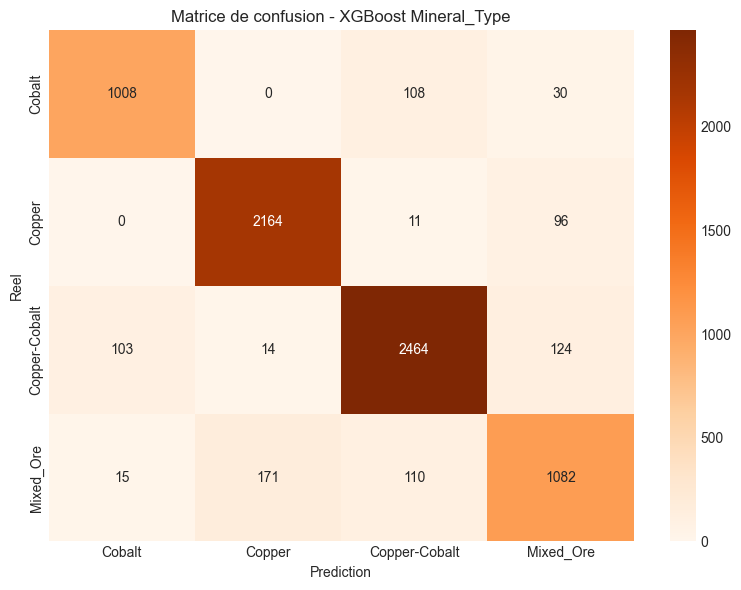


[OK] Evaluation XGBoost terminee


In [12]:
# ============================================================
# ENTRAINEMENT DE XGBOOST
# ============================================================

print("\n" + "="*60)
print("ENTRAINEMENT DE XGBOOST")
print("="*60)

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

# ============================================================
# IDENTIFICATION DU MINERAI STRATEGIQUE
# ============================================================

if 'mineral' in targets_available:

    print("\n" + "="*60)
    print("IDENTIFICATION DU MINERAI STRATEGIQUE")
    print("="*60)

    xgb_model.fit(X_train, y_train_mineral)

    y_pred_mineral = xgb_model.predict(X_test)

    print("\nAccuracy : {:.4f}".format(
        accuracy_score(y_test_mineral, y_pred_mineral)
    ))

    print("\nRapport de classification :")

    print(
        classification_report(
            y_test_mineral,
            y_pred_mineral,
            target_names=le_mineral.classes_
        )
    )

    results_mineral = evaluate_model_with_cv(
        xgb_model,
        X_train,
        y_train_mineral,
        'XGBoost',
        'Mineral_Type'
    )

    all_results.append(results_mineral)

    cm = confusion_matrix(
        y_test_mineral,
        y_pred_mineral
    )

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Oranges',
        xticklabels=le_mineral.classes_,
        yticklabels=le_mineral.classes_
    )

    plt.title(
        'Matrice de confusion - XGBoost Mineral_Type'
    )

    plt.xlabel('Prediction')
    plt.ylabel('Reel')

    plt.tight_layout()
    plt.show()

    print("\n[OK] Evaluation XGBoost terminee")

In [30]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm_model.fit(X_train, y_train_mineral)

y_pred = lgbm_model.predict(X_test)

print(classification_report(
    y_test_mineral,
    y_pred,
    target_names=le_mineral.classes_
))

results_lgbm = evaluate_model_with_cv(
    lgbm_model,
    X_train,
    y_train_mineral,
    'LightGBM',
    'Mineral_Type'
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 35000, number of used features: 9
[LightGBM] [Info] Start training from score -1.898645
[LightGBM] [Info] Start training from score -1.206834
[LightGBM] [Info] Start training from score -0.988247
[LightGBM] [Info] Start training from score -1.721168
               precision    recall  f1-score   support

       Cobalt       0.89      0.88      0.88      1146
       Copper       0.92      0.95      0.94      2271
Copper-Cobalt       0.92      0.91      0.91      2705
    Mixed_Ore       0.81      0.79      0.80      1378

     accuracy                           0.89      7500
    macro avg       0.88      0.88      0.88      7500
 weighted avg       0.89      0.89      0.89 

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train_mineral)

y_pred = svm_model.predict(X_test)

print(classification_report(
    y_test_mineral,
    y_pred,
    target_names=le_mineral.classes_
))

results_svm = evaluate_model_with_cv(
    svm_model,
    X_train,
    y_train_mineral,
    'SVM',
    'Mineral_Type'
)

               precision    recall  f1-score   support

       Cobalt       0.87      0.89      0.88      1146
       Copper       0.92      0.95      0.93      2271
Copper-Cobalt       0.92      0.90      0.91      2705
    Mixed_Ore       0.80      0.77      0.79      1378

     accuracy                           0.89      7500
    macro avg       0.88      0.88      0.88      7500
 weighted avg       0.89      0.89      0.89      7500


SVM - Mineral_Type


In [14]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128,64),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

mlp_model.fit(X_train, y_train_mineral)

y_pred = mlp_model.predict(X_test)

print(classification_report(
    y_test_mineral,
    y_pred,
    target_names=le_mineral.classes_
))

results_mlp = evaluate_model_with_cv(
    mlp_model,
    X_train,
    y_train_mineral,
    'MLP',
    'Mineral_Type'
)

               precision    recall  f1-score   support

       Cobalt       0.83      0.89      0.86      1146
       Copper       0.92      0.93      0.93      2271
Copper-Cobalt       0.90      0.88      0.89      2705
    Mixed_Ore       0.76      0.75      0.76      1378

     accuracy                           0.87      7500
    macro avg       0.85      0.86      0.86      7500
 weighted avg       0.87      0.87      0.87      7500


MLP - Mineral_Type

CROSS-VALIDATION (k=5)
----------------------------------------
Accuracy : 0.8589 (+/- 0.0038)
Precision : 0.8418 (+/- 0.0032)
Recall : 0.8386 (+/- 0.0048)
F1-score : 0.8400 (+/- 0.0040)

INTERVALLES DE CONFIANCE 95 %
Accuracy IC95 : [0.8515 ; 0.8662]
F1-score IC95 : [0.8322 ; 0.8478]


In [ ]:
# ============================================================
# COMPARAISON DES MODELES
# ============================================================

print("\n" + "="*60)
print("COMPARAISON DES MODELES")
print("="*60)

comparison_data = []

for result in all_results:

    row = {
        'Modele': result['model'],
        'Cible': result['target'],
        'Accuracy': round(result['accuracy']['mean'], 4),
        'Precision': round(result['precision']['mean'], 4),
        'Recall': round(result['recall']['mean'], 4),
        'F1-score': round(result['f1']['mean'], 4)
    }

    if 'roc_auc' in result:
        row['ROC-AUC'] = round(
            result['roc_auc']['mean'],
            4
        )
    else:
        row['ROC-AUC'] = np.nan

    comparison_data.append(row)

comparison_df = pd.DataFrame(
    comparison_data
)

print("\nTableau comparatif :")
print(comparison_df)

# Sauvegarde CSV
comparison_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        'comparaison_modeles.csv'
    ),
    index=False
)

print("\n[OK] Tableau sauvegarde")


COMPARAISON DES MODELES

Tableau comparatif :
          Modele            Cible  Accuracy  Precision  Recall  F1-score  \
0  Random Forest     Mineral_Type    0.8947     0.8792  0.8823    0.8806   
1  Random Forest   Impurity_Level    0.9302     0.9302  0.9302    0.9302   
2  Random Forest  Fraud_Detection    0.8492     0.5287  0.5004    0.4613   
3        XGBoost     Mineral_Type    0.8923     0.8786  0.8764    0.8774   

   ROC-AUC  
0      NaN  
1   0.9736  
2   0.5002  
3      NaN  

[OK] Tableau sauvegarde


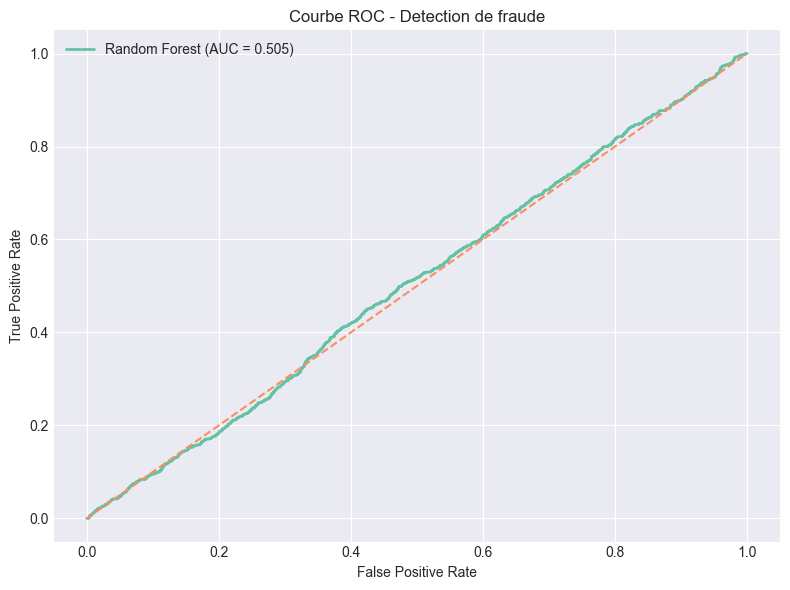

[OK] Courbe ROC sauvegardee


In [ ]:
# ============================================================
# COURBE ROC
# ============================================================

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

fpr, tpr, _ = roc_curve(
    y_test_fraud,
    y_proba_fraud
)

roc_auc = auc(
    fpr,
    tpr
)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label='Random Forest (AUC = {:.3f})'.format(
        roc_auc
    )
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title(
    'Courbe ROC - Detection de fraude'
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        VIZ_DIR,
        'roc_curve_fraud.png'
    ),
    dpi=300
)

plt.show()

print("[OK] Courbe ROC sauvegardee")

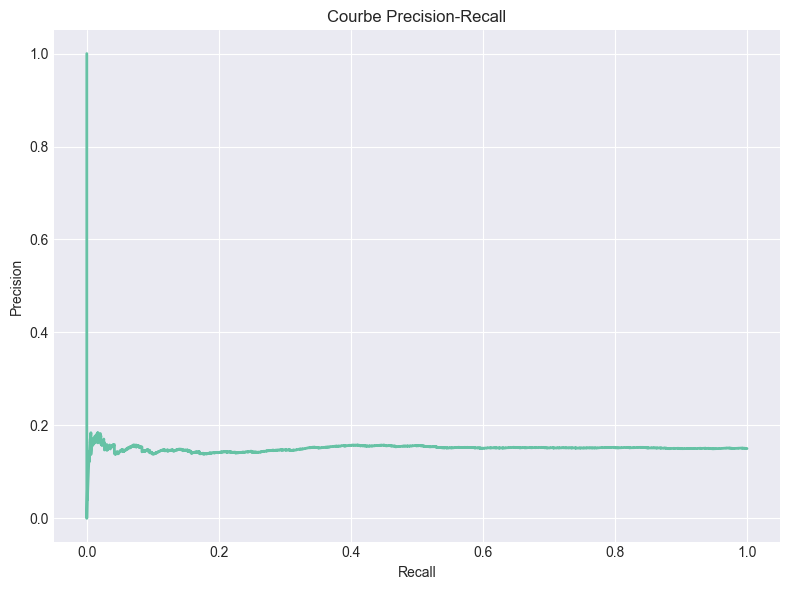

[OK] Courbe Precision-Recall sauvegardee


In [ ]:
# ============================================================
# COURBE PRECISION-RECALL
# ============================================================

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_test_fraud,
    y_proba_fraud
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title(
    'Courbe Precision-Recall'
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        VIZ_DIR,
        'precision_recall_curve.png'
    ),
    dpi=300
)

plt.show()

print("[OK] Courbe Precision-Recall sauvegardee")

In [ ]:
# ============================================================
# SAUVEGARDE DES MODELES
# ============================================================

import joblib

print("\n" + "="*60)
print("SAUVEGARDE DES MODELES")
print("="*60)

# Random Forest
if 'rf_model' in globals():

    joblib.dump(
        rf_model,
        os.path.join(
            MODELS_DIR,
            'random_forest.pkl'
        )
    )

    print("[OK] Random Forest sauvegarde")

# XGBoost
if 'xgb_model' in globals():

    joblib.dump(
        xgb_model,
        os.path.join(
            MODELS_DIR,
            'xgboost.pkl'
        )
    )

    print("[OK] XGBoost sauvegarde")

# LightGBM
if 'lgbm_model' in globals():

    joblib.dump(
        lgbm_model,
        os.path.join(
            MODELS_DIR,
            'lightgbm.pkl'
        )
    )

    print("[OK] LightGBM sauvegarde")

# SVM
if 'svm_model' in globals():

    joblib.dump(
        svm_model,
        os.path.join(
            MODELS_DIR,
            'svm.pkl'
        )
    )

    print("[OK] SVM sauvegarde")

# MLP
if 'mlp_model' in globals():

    joblib.dump(
        mlp_model,
        os.path.join(
            MODELS_DIR,
            'mlp.pkl'
        )
    )

    print("[OK] MLP sauvegarde")

print("\n[OK] Sauvegarde terminee")


SAUVEGARDE DES MODELES
[OK] Random Forest sauvegarde
[OK] XGBoost sauvegarde
[OK] SVM sauvegarde
[OK] MLP sauvegarde

[OK] Sauvegarde terminee


In [ ]:
# ============================================================
# SAUVEGARDE DES RESULTATS
# ============================================================

print("\n" + "="*60)
print("SAUVEGARDE DES RESULTATS")
print("="*60)

import json
import joblib

# ------------------------------------------------------------
# COMPARAISON DES MODELES
# ------------------------------------------------------------

if 'fraud_comparison_results' in globals() and len(fraud_comparison_results) > 0:

    json_filename = os.path.join(
        REPORTS_DIR,
        "fraud_model_comparison.json"
    )

    with open(
        json_filename,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            fraud_comparison_results,
            f,
            indent=2,
            ensure_ascii=False,
            default=str
        )

    print(
        "[OK] Comparaison des modeles sauvegardee"
    )

# ------------------------------------------------------------
# RESULTATS RANDOM FOREST
# ------------------------------------------------------------

if 'all_results' in globals() and len(all_results) > 0:

    rf_json_filename = os.path.join(
        REPORTS_DIR,
        "random_forest_results.json"
    )

    with open(
        rf_json_filename,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            all_results,
            f,
            indent=2,
            ensure_ascii=False,
            default=str
        )

    print(
        "[OK] Resultats Random Forest sauvegardes"
    )

# ------------------------------------------------------------
# SCALER
# ------------------------------------------------------------

if 'scaler' in globals():

    joblib.dump(
        scaler,
        os.path.join(
            MODELS_DIR,
            "scaler.pkl"
        )
    )

    print("[OK] Scaler sauvegarde")

# ------------------------------------------------------------
# LABEL ENCODERS
# ------------------------------------------------------------

if 'le_mineral' in globals():

    joblib.dump(
        le_mineral,
        os.path.join(
            MODELS_DIR,
            "label_encoder_mineral.pkl"
        )
    )

    print(
        "[OK] Label Encoder Mineral sauvegarde"
    )

if 'le_impurity' in globals():

    joblib.dump(
        le_impurity,
        os.path.join(
            MODELS_DIR,
            "label_encoder_impurity.pkl"
        )
    )

    print(
        "[OK] Label Encoder Impurity sauvegarde"
    )

# ------------------------------------------------------------
# MODELES IA
# ------------------------------------------------------------

if 'rf_model' in globals():

    joblib.dump(
        rf_model,
        os.path.join(
            MODELS_DIR,
            "random_forest.pkl"
        )
    )

    print(
        "[OK] Random Forest sauvegarde"
    )

if 'xgb_model' in globals():

    joblib.dump(
        xgb_model,
        os.path.join(
            MODELS_DIR,
            "xgboost.pkl"
        )
    )

    print(
        "[OK] XGBoost sauvegarde"
    )

if 'lgbm_model' in globals():

    joblib.dump(
        lgbm_model,
        os.path.join(
            MODELS_DIR,
            "lightgbm.pkl"
        )
    )

    print(
        "[OK] LightGBM sauvegarde"
    )

if 'svm_model' in globals():

    joblib.dump(
        svm_model,
        os.path.join(
            MODELS_DIR,
            "svm.pkl"
        )
    )

    print(
        "[OK] SVM sauvegarde"
    )

if 'mlp_model' in globals():

    joblib.dump(
        mlp_model,
        os.path.join(
            MODELS_DIR,
            "mlp.pkl"
        )
    )

    print(
        "[OK] MLP sauvegarde"
    )

# ------------------------------------------------------------
# RAPPORT FINAL
# ------------------------------------------------------------

summary_file = os.path.join(
    REPORTS_DIR,
    "resume_projet.txt"
)

with open(
    summary_file,
    "w",
    encoding="utf-8"
) as f:

    f.write("SYSTEME DE CERTIFICATION DES MINERAIS STRATEGIQUES\n")
    f.write("=" * 60 + "\n\n")

    f.write("Modules implementes :\n")
    f.write("- Identification des minerais\n")
    f.write("- Classification des impuretes\n")
    f.write("- Detection de fraude\n")
    f.write("- Certification Blockchain\n\n")

    f.write("Modeles testes :\n")
    f.write("- Random Forest\n")
    f.write("- XGBoost\n")
    f.write("- LightGBM\n")
    f.write("- SVM\n")
    f.write("- MLP\n")

print("[OK] Rapport final sauvegarde")

print("\n" + "="*60)
print("SAUVEGARDE TERMINEE AVEC SUCCES")
print("="*60)


SAUVEGARDE DES RESULTATS
[OK] Resultats Random Forest sauvegardes
[OK] Scaler sauvegarde
[OK] Label Encoder Mineral sauvegarde
[OK] Label Encoder Impurity sauvegarde
[OK] Random Forest sauvegarde
[OK] XGBoost sauvegarde
[OK] SVM sauvegarde
[OK] MLP sauvegarde
[OK] Rapport final sauvegarde

SAUVEGARDE TERMINEE AVEC SUCCES


In [ ]:
# ============================================================
# RAPPORT FINAL
# ============================================================

best_model = comparison_df.loc[
    comparison_df['F1-score'].idxmax()
]

print("\n" + "="*60)
print("RAPPORT FINAL")
print("="*60)

print("\nMeilleur modele :")
print(best_model['Modele'])

print("\nCible :")
print(best_model['Cible'])

print("\nPerformance :")
print("Accuracy  :", best_model['Accuracy'])
print("Precision :", best_model['Precision'])
print("Recall    :", best_model['Recall'])
print("F1-score  :", best_model['F1-score'])

if not pd.isna(best_model['ROC-AUC']):
    print(
        "ROC-AUC   :",
        best_model['ROC-AUC']
    )

print("\n[OK] Rapport final genere")


RAPPORT FINAL

Meilleur modele :
Random Forest

Cible :
Impurity_Level

Performance :
Accuracy  : 0.9302
Precision : 0.9302
Recall    : 0.9302
F1-score  : 0.9302
ROC-AUC   : 0.9736

[OK] Rapport final genere



IMPORTANCE DES VARIABLES

Importance des variables :
        Variable  Importance
7  Density_g_cm3    0.113602
3           Ni_%    0.112372
6     Moisture_%    0.112147
5            S_%    0.112103
2           Fe_%    0.112048
8  Weight_tonnes    0.111433
4           Mn_%    0.110419
0           Cu_%    0.108597
1           Co_%    0.107280


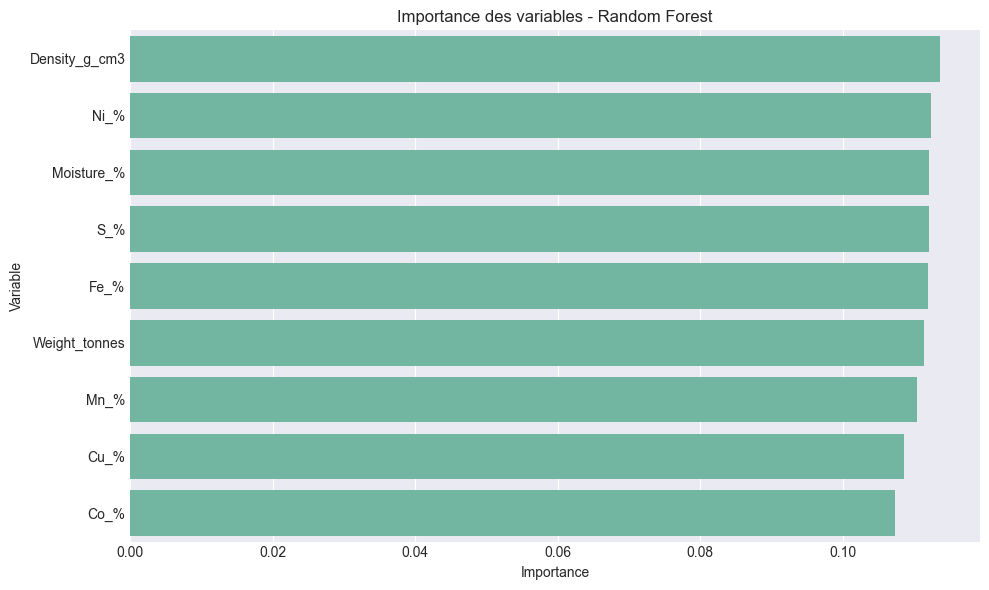


[OK] Importance des variables sauvegardee


In [ ]:
# ============================================================
# IMPORTANCE DES VARIABLES - RANDOM FOREST
# ============================================================

print("\n" + "="*60)
print("IMPORTANCE DES VARIABLES")
print("="*60)

if 'rf_model' in globals():

    importance_df = pd.DataFrame({
        'Variable': feature_columns,
        'Importance': rf_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by='Importance',
        ascending=False
    )

    print("\nImportance des variables :")
    print(importance_df)

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=importance_df,
        x='Importance',
        y='Variable'
    )

    plt.title(
        'Importance des variables - Random Forest'
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            VIZ_DIR,
            'feature_importance_rf.png'
        ),
        dpi=300
    )

    plt.show()

    print("\n[OK] Importance des variables sauvegardee")

In [ ]:
# ============================================================
# OPTIMISATION DU SEUIL DE DETECTION DE FRAUDE
# ============================================================

print("\n" + "="*60)
print("OPTIMISATION DU SEUIL FRAUDE")
print("="*60)

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

for threshold in thresholds:

    y_pred_thresh = (
        y_proba_fraud >= threshold
    ).astype(int)

    acc = accuracy_score(
        y_test_fraud,
        y_pred_thresh
    )

    prec = precision_score(
        y_test_fraud,
        y_pred_thresh,
        zero_division=0
    )

    rec = recall_score(
        y_test_fraud,
        y_pred_thresh,
        zero_division=0
    )

    f1 = f1_score(
        y_test_fraud,
        y_pred_thresh,
        zero_division=0
    )

    print(
        f"Seuil={threshold:.2f} | "
        f"Acc={acc:.4f} | "
        f"Prec={prec:.4f} | "
        f"Recall={rec:.4f} | "
        f"F1={f1:.4f}"
    )

print("\n[OK] Analyse des seuils terminee")


OPTIMISATION DU SEUIL FRAUDE
Seuil=0.30 | Acc=0.2604 | Prec=0.1517 | Recall=0.8560 | F1=0.2577
Seuil=0.35 | Acc=0.3929 | Prec=0.1519 | Recall=0.6649 | F1=0.2473
Seuil=0.40 | Acc=0.5724 | Prec=0.1562 | Recall=0.4204 | F1=0.2278
Seuil=0.45 | Acc=0.7657 | Prec=0.1473 | Recall=0.1173 | F1=0.1306
Seuil=0.50 | Acc=0.8477 | Prec=0.0526 | Recall=0.0009 | F1=0.0017

[OK] Analyse des seuils terminee


In [ ]:
# ============================================================
# TABLEAU FINAL POUR LE MEMOIRE
# ============================================================

print("\n" + "="*60)
print("TABLEAU FINAL DES PERFORMANCES")
print("="*60)

final_table = comparison_df.copy()

final_table = final_table.sort_values(
    by='F1-score',
    ascending=False
)

print(final_table)

final_table.to_excel(
    os.path.join(
        RESULTS_DIR,
        'tableau_final_performances.xlsx'
    ),
    index=False
)

print("\n[OK] Tableau Excel sauvegarde")


TABLEAU FINAL DES PERFORMANCES
          Modele            Cible  Accuracy  Precision  Recall  F1-score  \
1  Random Forest   Impurity_Level    0.9302     0.9302  0.9302    0.9302   
0  Random Forest     Mineral_Type    0.8947     0.8792  0.8823    0.8806   
3        XGBoost     Mineral_Type    0.8923     0.8786  0.8764    0.8774   
2  Random Forest  Fraud_Detection    0.8492     0.5287  0.5004    0.4613   

   ROC-AUC  
1   0.9736  
0      NaN  
3      NaN  
2   0.5002  


ModuleNotFoundError: No module named 'openpyxl'